In [26]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [27]:
import numpy as np
import pickle as pkl
from utils import *
from utils_plot import *
from tqdm import tqdm
import os
from utils_simple_access import *


In [28]:
glob.glob('./results/*')

['./results/sweep_L_A',
 './results/sweep_results_linear',
 './results/notebook_results']

In [29]:
# Run scan_L_A.py to generate the results for Fig2.ipynb
import pandas as pd

# Create an empty DataFrame with the specified headers
df = pd.DataFrame(columns=['L', 'A', 'NC1', 'margins', 'order'])

import glob

result_files = glob.glob('./results/sweep_L_A/*')

for file in tqdm(result_files):
    with open(file, 'rb') as f:
        data_dict = pkl.load(f)
    L = data_dict['C'].L
    A = data_dict['C'].max_move
    NC1 = calc_NC1_from_data_dict(data_dict)
    margins = multiclass_functional_margin_from_data_dict(data_dict)[0]
    order = get_order(data_dict)

    df = pd.concat([df, pd.DataFrame([{
        'L': L,
        'A': A,
        'NC1': NC1,
        'margins': margins,
        'order': 1-order
    }])], ignore_index=True)



  0%|                                                                                               | 0/178 [00:00<?, ?it/s]/tmp/ipykernel_858722/2865053762.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([{
 81%|█████████████████████████████████████████████████████████████████████▏               | 145/178 [03:53<00:53,  1.61s/it]


FileNotFoundError: [Errno 2] No such file or directory: './results/sweep_L_A/data_max_move_15_L_1.pkl'

In [ ]:
df

,L,A,NC1,margins,order
0,4,1,0.301855,"(0.013405882, 23, 6)",0.802081
1,5,7,0.005153,"(0.002762653, 86, 2)",0.996944
2,8,5,0.001168,"(0.0021707937, 59, 1)",0.999234
3,4,8,0.030293,"(0.002547752, 7, 6)",0.981228
4,1,6,0.428053,"(0.0038866326, 38, 4)",0.946839
...,...,...,...,...,...
85,2,6,0.065061,"(0.0036269128, 73, 2)",0.974344
86,2,3,0.116494,"(0.0063798577, 56, 7)",0.952759
87,1,1,0.696531,"(0.018819414, 12, 4)",0.624142
88,0,9,54.545448,"(0.002998054, 44, 4)",0.042872


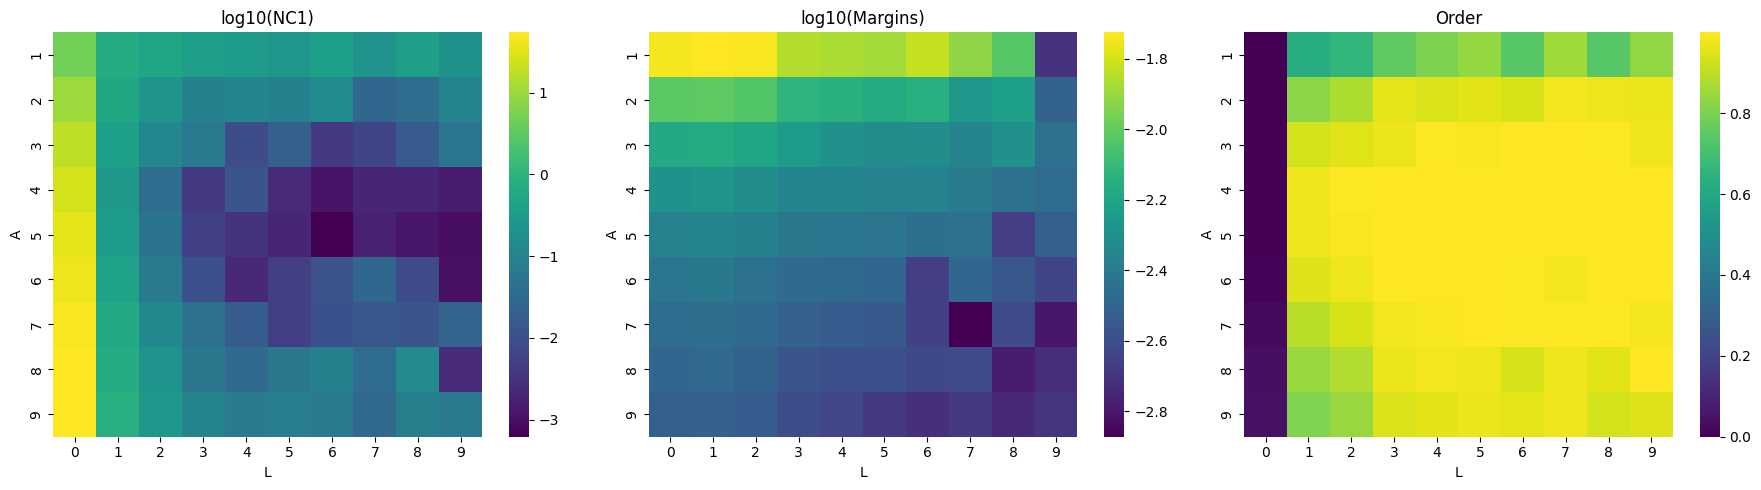

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure L and A are numeric
df['L'] = pd.to_numeric(df['L'])
df['A'] = pd.to_numeric(df['A'])

# Pivot tables for each metric
pivot_NC1 = df.pivot_table(index='A', columns='L', values='NC1', aggfunc='mean')
pivot_margins = df.pivot_table(index='A', columns='L', values='margins', aggfunc='mean')
pivot_order = df.pivot_table(index='A', columns='L', values='order', aggfunc='mean')

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

import numpy as np

# For NC1: log10, but avoid log(0) by setting a small floor
pivot_NC1_log = np.log10(np.clip(pivot_NC1, 1e-8, None))
sns.heatmap(pivot_NC1_log, ax=axs[0], cmap='viridis', annot=False, fmt=".2f")
axs[0].set_title('log10(NC1)')
axs[0].set_xlabel('L')
axs[0].set_ylabel('A')

# For margins: log10, but avoid log(0) by setting a small floor
pivot_margins_log = np.log10(np.clip(pivot_margins, 1e-8, None))
sns.heatmap(pivot_margins_log, ax=axs[1], cmap='viridis', annot=False, fmt=".2f")
axs[1].set_title('log10(Margins)')
axs[1].set_xlabel('L')
axs[1].set_ylabel('A')

sns.heatmap(pivot_order, ax=axs[2], cmap='viridis', annot=False, fmt=".2f")
axs[2].set_title('Order')
axs[2].set_xlabel('L')
axs[2].set_ylabel('A')

plt.tight_layout()
plt.show()


In [ ]:
accuracy_l = []

df = pd.DataFrame(columns=['L', 'A', 'accuracy', 'learning_rate'])
for file in tqdm(result_files):
    with open(file, 'rb') as f:
        data_dict = pkl.load(f)
    df = pd.concat([df, pd.DataFrame([{
        'L': data_dict['C'].L,
        'A': data_dict['C'].max_move,
        'accuracy': data_dict['accuracy_l'][-1],
        'learning_rate': data_dict['C'].learning_rate
    }])], ignore_index=True)


  0%|                                                                                                | 0/90 [00:00<?, ?it/s]/tmp/ipykernel_858722/4098436878.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([{
100%|███████████████████████████████████████████████████████████████████████████████████████| 90/90 [00:15<00:00,  5.78it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████| 90/90 [00:15<00:00,  5.72it/s]
/tmp/ipykernel_858722/13780411.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


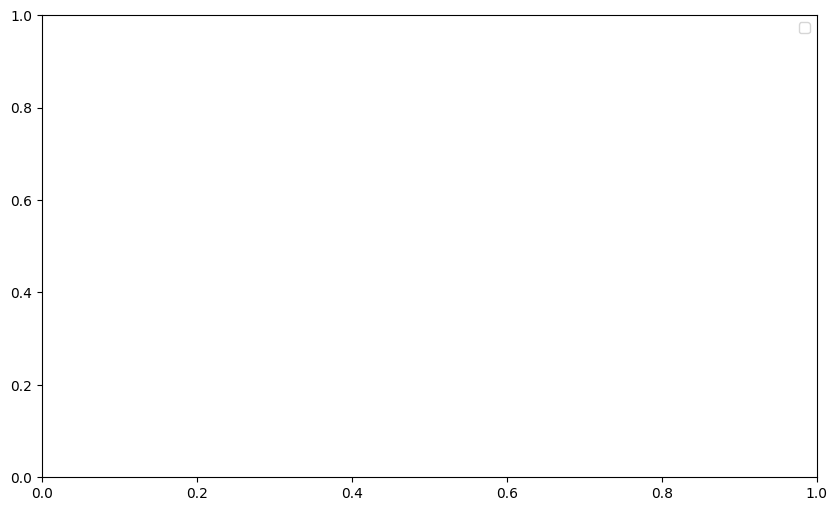

In [ ]:
plt.figure(figsize=(10, 6))
for file in tqdm(result_files):
    with open(file, 'rb') as f:
        data_dict = pkl.load(f)
    accuracy = data_dict['accuracy_l']
    if accuracy[-1] < 0.99:
        A = data_dict['C'].max_move
        L = data_dict['C'].L
        learning_rate = data_dict['C'].learning_rate
        plt.plot(accuracy, label=f'A={A}, L={L}, lr={learning_rate}')
plt.legend()


In [ ]:
data_dict = pkl.load(open('C:/Users/avivra/Desktop/cursor_projects/RepresentationShaping/results/sweep_L_A/data_max_move_1_L_7.pkl', 'rb'))
plt.plot(data_dict['accuracy_l'])

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/avivra/Desktop/cursor_projects/RepresentationShaping/results/sweep_L_A/data_max_move_1_L_7.pkl'

In [ ]:
v2 = data_dict['C'].L
v1 = data_dict['C'].max_move
(0.6 ** ((v2+v1)/2))

0.1296